**Lab: Data Standardization and Transformation Techniques**

**Objective**: Implement and compare various data transformation techniques used in preprocessing for machine learning pipelines.

We'll use:
- `scikit-learn`
- `pandas`, `numpy`
- `matplotlib` / `seaborn` for visualization
- California Housing dataset (as referenced in slides)

In [ ]:
# Install if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler,
    Normalizer, LabelEncoder, OrdinalEncoder, OneHotEncoder,
    PowerTransformer
)

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100



---

## 🔹 Step 1: Load & Inspect Data

Original data shape: (20640, 9)

First few rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


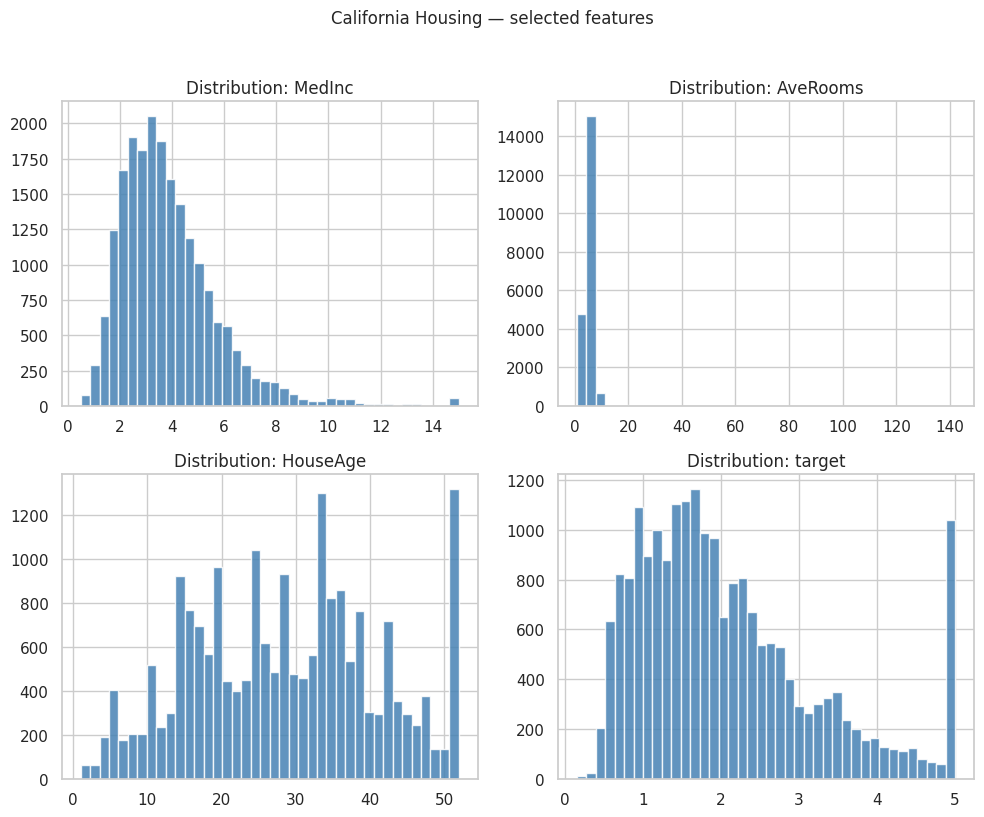

In [ ]:
# Load California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("Original data shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["MedInc", "AveRooms", "HouseAge", "target"]):
    ax.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribution: {col}")
plt.suptitle("California Housing — selected features", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()



---

## 🔹 Step 2: **Aesthetic Transformations** *(Slide 3)*

> These don’t change meaning—just format.

Since our dataset is numeric, we’ll simulate with a synthetic categorical column:

In [ ]:
# Simulate raw user input data
raw_df = pd.DataFrame({
    'address': ['123 Main St', '456 Oak street', '789 Pine ST'],
    'status': ['ACTIVE', 'inactive', 'Active'],
    'phone': ['(555) 123-4567', '555.987.6543', '5551234567']
})

# Aesthetic fixes
raw_df['address'] = raw_df['address'].str.replace(r'\bSt\b|\bstreet\b|\bST\b', 'Street', regex=True)
raw_df['status'] = raw_df['status'].str.capitalize()
raw_df['phone'] = raw_df['phone'].replace(r'\D', '', regex=True).apply(lambda x: f"({x[:3]}) {x[3:6]}-{x[6:10]}")

print("After aesthetic transformation:")
raw_df

After aesthetic transformation:


,address,status,phone
0,123 Main Street,Active,(555) 123-4567
1,456 Oak Street,Inactive,(555) 987-6543
2,789 Pine Street,Active,(555) 123-4567




---

## 🔹 Step 3: **Constructive Transformations** *(Slide 3)*

Add derived features:

New features added:


,rooms_per_person,bedroom_ratio
0,2.732919,0.146591
1,2.956685,0.155797
2,2.957661,0.129516
3,2.283154,0.184458
4,2.879646,0.172096


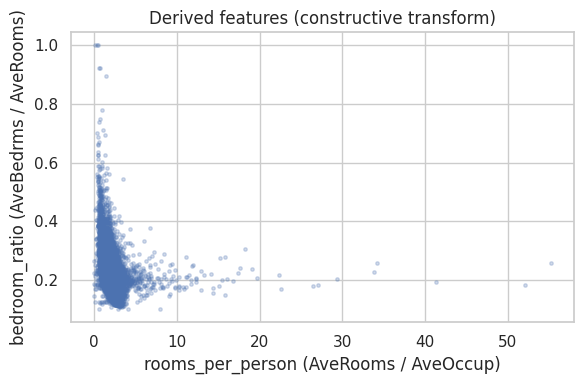

In [ ]:
# Example: derived features (sklearn California Housing has no "Households" column;
# AveOccup ≈ people per household, so AveRooms / AveOccup ≈ rooms per person)
df["rooms_per_person"] = df["AveRooms"] / df["AveOccup"].replace(0, np.nan)
df["bedroom_ratio"] = df["AveBedrms"] / df["AveRooms"]

print("New features added:")
display(df[["rooms_per_person", "bedroom_ratio"]].head())

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["rooms_per_person"], df["bedroom_ratio"], alpha=0.25, s=6)
ax.set_xlabel("rooms_per_person (AveRooms / AveOccup)")
ax.set_ylabel("bedroom_ratio (AveBedrms / AveRooms)")
ax.set_title("Derived features (constructive transform)")
plt.tight_layout()
plt.show()



---

## 🔹 Step 4: **Destructive Transformations** *(Slide 3)*

Remove duplicates & outliers:

Removed 1071 outlier rows.


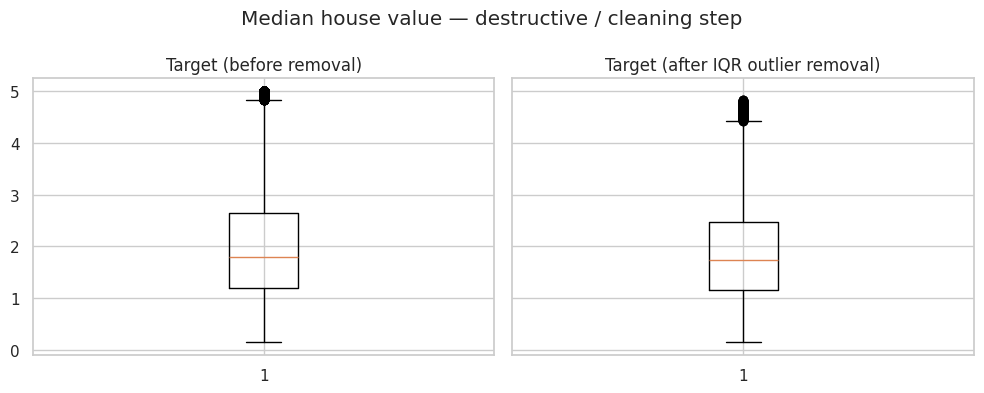

In [ ]:
# Remove duplicates (none expected here, but shown for completeness)
df_clean = df.drop_duplicates()

# Remove extreme outliers using IQR on target (median house value)
Q1 = df_clean['target'].quantile(0.25)
Q3 = df_clean['target'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ~((df_clean['target'] < (Q1 - 1.5 * IQR)) | (df_clean['target'] > (Q3 + 1.5 * IQR)))
df_no_outliers = df_clean[outlier_mask]

print(f"Removed {len(df_clean) - len(df_no_outliers)} outlier rows.")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].boxplot(df_clean["target"], vert=True)
axes[0].set_title("Target (before removal)")
axes[1].boxplot(df_no_outliers["target"], vert=True)
axes[1].set_title("Target (after IQR outlier removal)")
plt.suptitle("Median house value — destructive / cleaning step")
plt.tight_layout()
plt.show()



---

## 🔹 Step 5: **Structural Transformations** *(Slide 3)*

Rename, reorder, convert types:

In [ ]:
# Rename for clarity
df_renamed = df_no_outliers.rename(columns={'AveRooms': 'avg_rooms', 'MedInc': 'median_income'})

# Reorder columns: put target last
cols = [c for c in df_renamed.columns if c != 'target'] + ['target']
df_structured = df_renamed[cols]

# Ensure numeric types (already are, but good practice)
df_structured = df_structured.apply(pd.to_numeric, errors='coerce')

df_structured.head()

,median_income,HouseAge,avg_rooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedroom_ratio,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,2.732919,0.146591,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,2.956685,0.155797,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,2.957661,0.129516,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,2.283154,0.184458,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,2.879646,0.172096,3.422




---

## 🔹 Step 6: **Min-Max Scaling** *(Slides 5–7)*

Scale features to [0, 1]:

In [ ]:
X = df_structured.drop('target', axis=1)
y = df_structured['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

print("Min values in test set after scaling:", X_test_minmax.min(axis=0).round(3))
print("Max values in test set after scaling:", X_test_minmax.max(axis=0).round(3))

col_idx = X_train.columns.get_loc("median_income")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train.iloc[:, col_idx], bins=40, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_title("median_income (raw train)")
axes[1].hist(X_train_minmax[:, col_idx], bins=40, color="darkorange", alpha=0.85, edgecolor="white")
axes[1].set_title("median_income (Min–Max scaled)")
plt.suptitle("Min–Max scaling: same feature, [0, 1] range")
plt.tight_layout()
plt.show()

NameError: name 'df_structured' is not defined



---

## 🔹 Step 7: **Standardization (Z-score)** *(Slides 8–10)*

Center at 0, std = 1:

In [ ]:
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

print("Mean after standardization (train):", X_train_std.mean(axis=0).round(3))
print("Std after standardization (train):", X_train_std.std(axis=0).round(3))

col_idx = X_train.columns.get_loc("median_income")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train.iloc[:, col_idx], bins=40, color="steelblue", alpha=0.85, density=True, edgecolor="white")
axes[0].set_title("Raw")
axes[1].hist(X_train_std[:, col_idx], bins=40, color="seagreen", alpha=0.85, density=True, edgecolor="white")
axes[1].set_title("Standardized (μ≈0, σ≈1)")
plt.suptitle("median_income: distribution shape vs z-score scaling")
plt.tight_layout()
plt.show()



---

## 🔹 Step 8: **L2 Normalization** *(Slides 11–12)*

Normalize each sample (row) to unit norm:

In [ ]:
l2_normalizer = Normalizer(norm='l2')
X_train_l2 = l2_normalizer.fit_transform(X_train)
X_test_l2 = l2_normalizer.transform(X_test)

# Check norm of first row
print("L2 norm of first sample:", np.linalg.norm(X_train_l2[0]))

row_norms_before = np.linalg.norm(X_train.to_numpy(), axis=1)
row_norms_after = np.linalg.norm(X_train_l2, axis=1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(row_norms_before, bins=50, alpha=0.55, label="Row L2 norm (before)", color="steelblue")
ax.hist(row_norms_after, bins=50, alpha=0.55, label="After Normalizer (≈1)", color="coral")
ax.legend()
ax.set_title("L2 Normalizer: each row scaled to unit norm")
plt.tight_layout()
plt.show()



---

## 🔹 Step 9: **Max-Abs Scaling** *(Slide 13)*

Scale by max absolute value → [-1, 1]:

In [ ]:
maxabs_scaler = MaxAbsScaler()
X_train_maxabs = maxabs_scaler.fit_transform(X_train)
X_test_maxabs = maxabs_scaler.transform(X_test)

print("Max abs scaled range (approx):", X_test_maxabs.min(), "to", X_test_maxabs.max())

col_idx = X_train.columns.get_loc("median_income")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train.iloc[:, col_idx], bins=40, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_title("Raw median_income")
axes[1].hist(X_train_maxabs[:, col_idx], bins=40, color="mediumpurple", alpha=0.85, edgecolor="white")
axes[1].set_title("MaxAbs scaled (÷ max |x|)")
plt.suptitle("MaxAbsScaler preserves sparsity; scales by largest magnitude")
plt.tight_layout()
plt.show()



---

## 🔹 Step 10: **Robust Scaling (IQR-based)** *(Slide 13)*

Robust to outliers:

In [ ]:
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

print("Median (should be ~0):", np.median(X_train_robust, axis=0)[:3])

col_idx = X_train.columns.get_loc("median_income")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train_std[:, col_idx], bins=40, color="seagreen", alpha=0.7, label="StandardScaler", edgecolor="white")
axes[0].hist(X_train_robust[:, col_idx], bins=40, color="darkorange", alpha=0.45, label="RobustScaler", edgecolor="white")
axes[0].legend()
axes[0].set_title("StandardScaler vs RobustScaler (median_income)")
axes[1].boxplot([X_train_std[:, col_idx], X_train_robust[:, col_idx]], labels=["Standard", "Robust"])
axes[1].set_title("Spread comparison (outlier sensitivity)")
plt.suptitle("RobustScaler uses median & IQR — less driven by extremes")
plt.tight_layout()
plt.show()



---

## 🔹 Step 11: **Categorical Encoding Examples** *(Slides 14–19)*

We’ll create synthetic categorical

In [ ]:
cat_data = pd.DataFrame({
    'color': ['Red', 'Green', 'Blue', 'Green', 'Red'],
    'size': ['S', 'XS', 'L', 'M', 'S'],
    'city': ['London', 'Manchester', 'Bristol', 'London', 'Bristol'],
    'rating': ['Poor', 'Good', 'Excellent', 'Good', 'Poor']
})



### ✅ One-Hot Encoding (Nominal)

In [ ]:
ohe = OneHotEncoder(sparse_output=False)
encoded_ohe = ohe.fit_transform(cat_data[["color", "city"]])
enc_df = pd.DataFrame(encoded_ohe, columns=ohe.get_feature_names_out())
display(enc_df)

plt.figure(figsize=(8, 3))
sns.heatmap(enc_df.T, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "value"})
plt.title("One-hot encoded features (nominal categories)")
plt.xlabel("sample index")
plt.ylabel("encoded column")
plt.tight_layout()
plt.show()



### ✅ Label Encoding (Ordinal or Tree Models)

In [ ]:
le = LabelEncoder()
cat_data['color_encoded'] = le.fit_transform(cat_data['color'])
cat_data[['color', 'color_encoded']]



### ✅ Ordinal Encoding (with order)

In [ ]:
size_order = ['XS', 'S', 'M', 'L']
ord_enc = OrdinalEncoder(categories=[size_order])
cat_data['size_ord'] = ord_enc.fit_transform(cat_data[['size']])
cat_data[['size', 'size_ord']]



### ✅ Target Encoding (simulate with target)

In [ ]:
# Simulated target
cat_data["price"] = [100, 150, 200, 160, 110]

# Target encode 'city'
target_mean = cat_data.groupby("city")["price"].mean()
cat_data["city_target_enc"] = cat_data["city"].map(target_mean)
display(cat_data)

fig, ax = plt.subplots(figsize=(6, 3.5))
target_mean.sort_values().plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Target encoding: mean price per city (illustration)")
ax.set_ylabel("mean price")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()



Continuing from where we left off, here is the **complete lab** covering **numerical variable transformations** (Slides 20–26) and wrapping up with best practices.

---

## 🔹 Step 12: **Why Transform Numerical Variables?** *(Slide 20)*

Many ML models (e.g., linear regression, SVM) assume:
- Linear relationships
- Normally distributed errors
- Homoscedasticity (constant variance)

Skewed features violate these assumptions. We’ll visualize and fix skew.

In [ ]:
# Check skewness of original features
skew_vals = df_structured.drop("target", axis=1).skew().sort_values(ascending=False)
print("Top skewed features:")
display(skew_vals.head())

fig, ax = plt.subplots(figsize=(8, 4))
skew_vals.head(8).sort_values().plot(kind="barh", ax=ax, color="coral")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Most skewed features (why transforms help)")
ax.set_xlabel("skewness")
plt.tight_layout()
plt.show()



---

## 🔹 Step 13: **Q-Q Plot to Assess Normality** *(Slide 21)*

In [ ]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_structured["median_income"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Histogram: median_income")
stats.probplot(df_structured["median_income"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs normal")
plt.suptitle("Assessing normality (median_income)")
plt.tight_layout()
plt.show()



> If points deviate from the diagonal → non-normal → consider transformation.

---

## 🔹 Step 14: **Log Transformation** *(Slide 22)*

Useful for right-skewed

In [ ]:
from sklearn.preprocessing import FunctionTransformer

# Ensure no zeros/negatives
X_log_safe = X_train.copy()
X_log_safe = np.where(X_log_safe <= 0, 1e-6, X_log_safe)  # Avoid log(0)

log_transformer = FunctionTransformer(np.log1p)  # log(x + 1)
X_train_log = log_transformer.fit_transform(X_log_safe)
X_test_log = log_transformer.transform(np.where(X_test <= 0, 1e-6, X_test))

mi_idx = X_train.columns.get_loc("median_income")
orig_skew = pd.Series(X_train.iloc[:, mi_idx]).skew()
new_skew = pd.Series(X_train_log[:, mi_idx]).skew()
print(f"Original skew: {orig_skew:.2f} → Log-transformed skew: {new_skew:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train.iloc[:, mi_idx], bins=40, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_title("median_income (raw)")
axes[1].hist(X_train_log[:, mi_idx], bins=40, color="teal", alpha=0.85, edgecolor="white")
axes[1].set_title("log1p(median_income)")
plt.suptitle("Log transform reduces right skew")
plt.tight_layout()
plt.show()



---

## 🔹 Step 15: **Reciprocal & Square Root** *(Slide 23)*

In [ ]:
# Reciprocal (for strong right skew)
recip_transformer = FunctionTransformer(lambda x: 1 / (x + 1e-6))
X_train_recip = recip_transformer.fit_transform(X_train)

# Square root (for count-like data)
sqrt_transformer = FunctionTransformer(np.sqrt)
X_train_sqrt = sqrt_transformer.fit_transform(np.abs(X_train))  # abs for safety

j = X_train.columns.get_loc("median_income")
R = np.asarray(X_train_recip)
S = np.asarray(X_train_sqrt)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].hist(X_train.iloc[:, j], bins=40, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_title("Raw")
axes[1].hist(R[:, j], bins=40, color="darkorange", alpha=0.85, edgecolor="white")
axes[1].set_title("Reciprocal 1/(x+ε)")
axes[2].hist(S[:, j], bins=40, color="seagreen", alpha=0.85, edgecolor="white")
axes[2].set_title("sqrt(|x|)")
plt.suptitle("Alternative transforms on median_income (example column)")
plt.tight_layout()
plt.show()



---

## 🔹 Step 16: **Box-Cox Transformation** *(Slides 24–25)*

Only works for **positive values**:

In [ ]:
from sklearn.preprocessing import PowerTransformer

# Box-Cox requires strictly positive, non-constant columns (exclude e.g. Longitude)
pos_cols = [
    c
    for c in X_train.columns
    if (X_train[c] > 0).all() and X_train[c].nunique() > 1
]
X_train_bc = np.clip(X_train[pos_cols].to_numpy(), 1e-6, None)
X_test_bc = np.clip(X_test[pos_cols].to_numpy(), 1e-6, None)

boxcox = PowerTransformer(method="box-cox", standardize=True)
X_train_boxcox = boxcox.fit_transform(X_train_bc)
X_test_boxcox = boxcox.transform(X_test_bc)

j = pos_cols.index("median_income") if "median_income" in pos_cols else 0
bc_skew = pd.Series(X_train_boxcox[:, j]).skew()
print(f"Box-Cox skew (median_income column in subset): {bc_skew:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train[pos_cols[j]], bins=40, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_title(f"Raw: {pos_cols[j]}")
axes[1].hist(X_train_boxcox[:, j], bins=40, color="purple", alpha=0.85, edgecolor="white")
axes[1].set_title("After Box–Cox (+ standardize)")
plt.suptitle("Box–Cox: positive features only; toward Gaussian-like marginals")
plt.tight_layout()
plt.show()



---

## 🔹 Step 17: **Yeo-Johnson Transformation** *(Slide 26)*

Works with **zero, negative, and positive** values:

In [ ]:
yeo = PowerTransformer(method="yeo-johnson", standardize=True)
X_train_yj = yeo.fit_transform(X_train)
X_test_yj = yeo.transform(X_test)

feat0 = X_train.columns[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(X_train.iloc[:, 0], bins=40, alpha=0.85, color="steelblue", edgecolor="white", label="Original")
axes[0].set_title(f"Raw: {feat0}")
axes[1].hist(X_train_yj[:, 0], bins=40, alpha=0.85, color="darkorange", edgecolor="white", label="Yeo–Johnson")
axes[1].set_title("After Yeo–Johnson (+ standardize)")
plt.suptitle("Yeo–Johnson: works with non-positive values; stabilizes skew")
plt.tight_layout()
plt.show()



---

## ✅ **Summary Table of Techniques**

| Technique               | Use Case                                      | Handles Negatives? | Bounded? | Outlier Robust? |
|------------------------|-----------------------------------------------|--------------------|----------|------------------|
| Min-Max Scaling        | Neural nets, image data                       | Yes                | Yes [0,1]| ❌               |
| Standardization        | Linear models, PCA                            | Yes                | No       | ❌               |
| Robust Scaling         | Data with outliers                            | Yes                | No       | ✅               |
| MaxAbs Scaling         | Sparse data                                   | Yes                | [-1,1]   | ❌               |
| L2 Normalization       | Text, clustering, cosine similarity           | Yes                | Unit norm| ❌               |
| One-Hot Encoding       | Nominal low-cardinality                       | —                  | —        | —                |
| Target Encoding        | High-cardinality categories                   | —                  | —        | ⚠️ (leakage risk)|
| Log / Box-Cox          | Right-skewed numeric                          | Box-Cox: ❌        | No       | ❌               |
| Yeo-Johnson            | Skewed numeric (any sign)                     | ✅                 | No       | ❌               |

---

## 🧪 Final Lab Exercise (Optional)

**Task**: Build a simple pipeline comparing model performance (e.g., Ridge Regression) using:
- Raw data
- MinMax-scaled data
- Yeo-Johnson + Standardized data

Which gives lowest RMSE?

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

models = {
    'Raw': X_train,
    'MinMax': X_train_minmax,
    'YeoJohnson+Std': X_train_yj  # already standardized by PowerTransformer
}

results = {}
for name, X in models.items():
    model = Ridge(alpha=1.0).fit(X, y_train)
    y_pred = model.predict(X)  # train-set evaluation (same matrix as fit)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    results[name] = rmse

print("Train RMSE comparison:", results)

fig, ax = plt.subplots(figsize=(7, 4))
names = list(results.keys())
ax.bar(names, [results[k] for k in names], color=["steelblue", "darkorange", "seagreen"], edgecolor="black", alpha=0.9)
ax.set_ylabel("Train RMSE")
ax.set_title("Ridge regression — same α, different preprocessing")
plt.tight_layout()
plt.show()